In [1]:
input_1 = 'file_input_uploads/Factordata-20241230-182848.zip'

In [2]:
!pip install openpyxl
!pip install matplotlib-venn


import os
print(os.listdir("file_input_uploads"))


[notice] A new release of pip is available: 23.0.1 -> 24.3.1
[notice] To update, run: pip install --upgrade pip
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.3/40.3 kB 6.4 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for matplotlib-venn: filename=matplotlib_venn-1.1.1-py3-none-any.whl size=45290 sha256=fd71b2bc76d068ab5e8742cc99db53e36d9934ffa09fad3d53f9a1b442c9fcc4
  Stored in directory: /root/.cache/pip/wheels/5c/4b/48/d68a6531b1e1e7411520ab9f395994eb1ee2ffafd6837b7f6c
Successfully built matplotlib-venn

[notice] A new release of pip is available: 23.0.1 -> 24.3.1
[notice] To update, run: pip install --upgrade pip
['Factordata.zip']


In [3]:
!pip install imblearn==0.0

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 258.3/258.3 kB 24.5 MB/s eta 0:00:00

[notice] A new release of pip is available: 23.0.1 -> 24.3.1
[notice] To update, run: pip install --upgrade pip


In [4]:
import os
import pandas as pd
import numpy as np
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from imblearn.over_sampling import SMOTE
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import Dense, Dropout, LSTM, Input
from tensorflow.keras.callbacks import EarlyStopping
import logging
from datetime import datetime

# Configuration Class
class Config:
    def __init__(self):
        self.RANDOM_STATE = 42
        self.START_DATE = '2014-01-01'
        self.END_DATE = '2024-12-31'
        self.FACTOR_PATH = 'Factordata_2'
        self.OUTPUT_DIR = os.path.join(self.FACTOR_PATH, 'analysis_output')
        os.makedirs(self.OUTPUT_DIR, exist_ok=True)
        self.FACTOR_COLUMNS = [
            'Alpha..annualisiert.',
            'Value.Growth',
            'Small.Large',
            'Momentum',
            'Volatility'
        ]
        self.NN_BATCH_SIZE = 32
        self.NN_EPOCHS = 10
        self.NN_PATIENCE = 10
        self.VALIDATION_SPLIT = 0.2
        self.LAG_PERIODS = [1, 2, 4]
        self.ROLLING_WINDOWS = [4, 8]
        self.AE_EPOCHS = 50
        self.AE_BATCH_SIZE = 32

# Logger setup
def setup_logger():
    logger = logging.getLogger('financial_analysis')
    if not logger.hasHandlers():
        logger.setLevel(logging.INFO)
        c_handler = logging.StreamHandler()
        f_handler = logging.FileHandler(f'analysis_{datetime.now().strftime("%Y%m%d_%H%M%S")}.log')
        log_format = logging.Formatter('%(asctime)s - %(levelname)s - %(message)s')
        c_handler.setFormatter(log_format)
        f_handler.setFormatter(log_format)
        logger.addHandler(c_handler)
        logger.addHandler(f_handler)
    return logger

def load_economic_data(logger):
    """Load and combine economic indicator data."""
    try:
        logger.info("Loading economic data...")
        gdp = pd.read_csv('gdp_data.csv')
        gdp['date'] = pd.to_datetime(gdp['year_quarter']).dt.strftime('%Y-%m-%d')
        gdp['date'] = pd.to_datetime(gdp['date'])
        gdp = gdp[['date', 'real_q']].rename(columns={'real_q': 'gdp'})

        unemp = pd.read_csv('combined_unemployment_data.csv', sep=';')
        unemp['date'] = pd.to_datetime(unemp['Date']).dt.strftime('%Y-%m-%d')
        unemp['date'] = pd.to_datetime(unemp['date'])
        unemp = unemp[['date', 'UnemploymentRate']]

        data = pd.merge_asof(
            gdp.sort_values('date'),
            unemp.sort_values('date'),
            on='date',
            direction='nearest'
        )
        logger.info(f"Economic data loaded: {data.shape}")
        return data
    except Exception as e:
        logger.error(f"Error loading economic data: {e}")
        raise

def create_features(data, config, logger):
    """Generate features from economic data."""
    logger.info("Creating features...")
    features = []
    numeric_cols = data.select_dtypes(include=[np.number]).columns

    # Base features
    for col in numeric_cols:
        features.append(pd.DataFrame({f"{col}_base": data[col]}))

    # Lagged features
    for col in numeric_cols:
        for lag in config.LAG_PERIODS:
            features.append(pd.DataFrame({
                f"{col}_lag{lag}": data[col].shift(lag)
            }))

    # Rolling window features
    for col in numeric_cols:
        for window in config.ROLLING_WINDOWS:
            rolling = data[col].rolling(window=window, min_periods=1)
            features.append(pd.DataFrame({
                f"{col}_roll_mean_{window}": rolling.mean(),
                f"{col}_roll_std_{window}": rolling.std()
            }))

    features_df = pd.concat(features, axis=1)
    features_df.insert(0, 'date', data['date'])
    logger.info(f"Features created: {features_df.shape}")
    return features_df

def create_autoencoder(input_dim):
    """Create and return an autoencoder model."""
    input_layer = Input(shape=(input_dim,))
    encoded = Dense(64, activation='relu')(input_layer)
    encoded = Dense(32, activation='relu')(encoded)
    decoded = Dense(64, activation='relu')(encoded)
    output_layer = Dense(input_dim, activation='sigmoid')(decoded)

    autoencoder = Model(inputs=input_layer, outputs=output_layer)
    autoencoder.compile(optimizer='adam', loss='mse')
    return autoencoder

def detect_outliers_with_autoencoder(data, config, logger):
    """Use an autoencoder to detect outliers based on reconstruction error."""
    logger.info("Training autoencoder for outlier detection...")
    numeric_data = data.select_dtypes(include=[np.number])
    scaler = StandardScaler()
    data_scaled = scaler.fit_transform(numeric_data)

    autoencoder = create_autoencoder(input_dim=data_scaled.shape[1])
    autoencoder.fit(
        data_scaled, data_scaled,
        epochs=config.AE_EPOCHS,
        batch_size=config.AE_BATCH_SIZE,
        validation_split=0.2,
        verbose=0
    )

    reconstruction = autoencoder.predict(data_scaled)
    reconstruction_error = np.mean(np.square(data_scaled - reconstruction), axis=1)

    threshold = np.percentile(reconstruction_error, 95)  # Top 5% as outliers
    data['outlier'] = (reconstruction_error > threshold).astype(int)

    logger.info(f"Outliers detected: {data['outlier'].sum()} out of {len(data)}")
    return data

def load_and_process_data(file_path, economic_features, config, logger):
    """Load and align factor data with economic features."""
    try:
        # Load factor data
        factors = pd.read_excel(file_path)
        
        # Convert dates to proper format
        factors['date'] = pd.to_datetime(factors['Date']).dt.strftime('%Y-%m-%d')
        factors['date'] = pd.to_datetime(factors['date'])
        economic_features['date'] = pd.to_datetime(economic_features['date'])
        
        # Align dates between features and factors
        common_data = pd.merge(
            economic_features,
            factors,
            on='date',
            how='inner'
        )
        
        logger.info(f"Aligned data shape: {common_data.shape}")
        
        if len(common_data) > 0:
            # Detect outliers
            common_data = detect_outliers_with_autoencoder(common_data, config, logger)

            # Prepare features (exclude date and factor columns)
            feature_columns = [
                col for col in common_data.columns 
                if col not in ['date'] + config.FACTOR_COLUMNS + ['outlier']
            ]
            
            # Ensure all feature columns are numeric
            X = common_data[feature_columns].select_dtypes(include=[np.number])
            
            # Use the outlier column as the target
            y = common_data[['outlier']]
            
            return X, y
        else:
            logger.warning(f"No common dates found in {file_path}")
            return None, None
            
    except Exception as e:
        logger.error(f"Error processing {file_path}: {e}")
        return None, None

def train_model(X_train, y_train, logger, n_neighbors=6):
    """Train a KNeighborsClassifier dynamically handling small datasets."""
    try:
        n_samples = X_train.shape[0]
        n_neighbors = min(n_neighbors, n_samples)
        
        # Log class distribution before SMOTE
        unique, counts = np.unique(y_train, return_counts=True)
        logger.info(f"Class distribution before SMOTE: {dict(zip(unique, counts))}")
        
        # Add SMOTE for balancing
        smote = SMOTE(random_state=42)
        X_balanced, y_balanced = smote.fit_resample(X_train, y_train)
        
        # Log class distribution after SMOTE
        unique_balanced, counts_balanced = np.unique(y_balanced, return_counts=True)
        logger.info(f"Class distribution after SMOTE: {dict(zip(unique_balanced, counts_balanced))}")
        
        logger.info(f"Original dataset shape: {X_train.shape}")
        logger.info(f"Resampled dataset shape: {X_balanced.shape}")
        
        model = KNeighborsClassifier(n_neighbors=n_neighbors)
        model.fit(X_balanced, y_balanced)
        return model
    except Exception as e:
        logger.error(f"Error training model: {e}")
        raise

# Function to create and compile an LSTM model
def create_lstm_model(input_dim, output_dim):
    """Create an LSTM model."""
    model = Sequential([
        LSTM(128, input_shape=(input_dim[1], input_dim[2]), return_sequences=True),
        Dropout(0.3),
        LSTM(64, return_sequences=False),
        Dropout(0.2),
        Dense(32, activation='relu'),
        Dense(output_dim, activation='sigmoid')
    ])
    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    return model

def train_evaluate_lstm(X, y, config, logger, output_path):
    try:
        # Apply SMOTE before scaling, with k_neighbors=1 for small samples
        logger.info(f"Original class distribution: {dict(zip(*np.unique(y, return_counts=True)))}")
        
        # Get count of minority class
        unique, counts = np.unique(y, return_counts=True)
        min_samples = min(counts)
        
        # Adjust k_neighbors based on minority class size
        k_neighbors = min(min_samples - 1, 5)  # k must be less than min_samples
        logger.info(f"Using k_neighbors={k_neighbors} for SMOTE")
        
        smote = SMOTE(random_state=42, k_neighbors=k_neighbors)
        X_balanced, y_balanced = smote.fit_resample(X, y)
        logger.info(f"Balanced class distribution: {dict(zip(*np.unique(y_balanced, return_counts=True)))}")
        
        scaler = StandardScaler()
        X_scaled = scaler.fit_transform(X_balanced)

        # Reshape data for LSTM [samples, timesteps, features]
        X_reshaped = X_scaled.reshape((X_scaled.shape[0], X_scaled.shape[1], 1))
        
        # Convert y_balanced to correct format
        y_balanced = np.array(y_balanced).reshape(-1, 1)  # Reshape to match expected dimensions

        # Initialize LSTM model
        model = create_lstm_model(X_reshaped.shape, y_balanced.shape[1])
        early_stopping = EarlyStopping(patience=config.NN_PATIENCE, restore_best_weights=True)

        # Train model
        history = model.fit(
            X_reshaped, y_balanced,  # Use y_balanced instead of y
            epochs=config.NN_EPOCHS,
            batch_size=config.NN_BATCH_SIZE,
            validation_split=config.VALIDATION_SPLIT,
            callbacks=[early_stopping],
            verbose=1
        )

        # Log training summary
        logger.info(f"Model training complete with final validation loss: {min(history.history['val_loss'])}")

        # Generate predictions
        predictions = model.predict(X_reshaped)
        logger.info(f"Predictions generated for mandate")

        # Save predictions
        prediction_df = pd.DataFrame(predictions, columns=[f"Pred_{i}" for i in range(predictions.shape[1])])
        prediction_df.to_csv(output_path, index=False)
        logger.info(f"Predictions saved to {output_path}")

        return model, predictions
    except Exception as e:
        logger.error(f"Error in training LSTM model: {e}")
        raise
        
# Main function
def main():
    logger = setup_logger()
    try:
        config = Config()

        # Load and process economic data
        economic_data = load_economic_data(logger)
        economic_data['date'] = economic_data['date'].dt.strftime('%Y-%m-%d')
        economic_data['date'] = pd.to_datetime(economic_data['date'])
        economic_features = create_features(economic_data, config, logger)

        # Process each factor file
        for file_name in os.listdir(config.FACTOR_PATH):
            if not file_name.endswith('.xlsx'):
                continue

            logger.info(f"Processing {file_name}")
            X, y = load_and_process_data(
                os.path.join(config.FACTOR_PATH, file_name),
                economic_features,
                config,
                logger
            )
            if X is None or y is None:
                logger.warning(f"Skipping {file_name} due to data issues")
                continue
            if len(X) == 0 or len(y) == 0:
                logger.warning(f"No valid data for {file_name}")
                continue

            # Output path for predictions
            output_path = os.path.join(config.OUTPUT_DIR, f"{os.path.splitext(file_name)[0]}_predictions.csv")

            # Train, evaluate, and save predictions
            train_evaluate_lstm(X, y, config, logger, output_path)
    except Exception as e:
        logger.error(f"Error in main execution: {e}")
        raise

if __name__ == "__main__":
    main()


2025-01-08 08:40:36.275732: I tensorflow/core/util/port.cc:113] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-01-08 08:40:36.329841: I external/local_tsl/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2025-01-08 08:40:36.360886: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2025-01-08 08:40:36.360997: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2025-01-08 08:40:36.361952: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to

In [5]:
# Redefine the directory and list of prediction files
output_dir = 'Factordata_2/analysis_output'

# Assuming the directory and files are accessible
try:
    prediction_files = [f for f in os.listdir(output_dir) if f.endswith('_predictions.csv')]

    # Initialize an empty list for summaries
    predictions_summary_list = []

    # Process each prediction file
    for file in prediction_files:
        file_path = os.path.join(output_dir, file)
        try:
            # Load predictions
            predictions = pd.read_csv(file_path)
            
            # Calculate summary statistics
            summary = {
                'File': file,
                'Mean': predictions.mean().mean(),
                'Min': predictions.min().min(),
                'Max': predictions.max().max(),
                'Std': predictions.std().mean(),
                'Num_Predictions': predictions.shape[0]
            }
            predictions_summary_list.append(summary)
        except Exception as e:
            predictions_summary_list.append({'File': file, 'Error': str(e)})

    # Convert the summary list to a DataFrame
    predictions_summary_df = pd.DataFrame(predictions_summary_list)

    # Print the summarized statistics
    print(predictions_summary_df)
except FileNotFoundError as e:
    print(f"Error: {e}. Please ensure the directory exists and contains the prediction files.")


                            File      Mean       Min       Max       Std  \
0          21216_predictions.csv  0.487352  0.037433  0.966109  0.356247   
1           3645_predictions.csv  0.355775  0.002174  0.938147  0.371069   
2        Finreon_predictions.csv  0.414594  0.014472  0.946136  0.340654   
3            GAM_predictions.csv  0.362132  0.002661  0.892264  0.375387   
4            IAM_predictions.csv  0.322950  0.006548  0.800013  0.283351   
5             Lo_predictions.csv  0.327973  0.008832  0.926103  0.361107   
6         Pictet_predictions.csv  0.465693  0.016790  0.985036  0.401031   
7           SGKB_predictions.csv  0.294812  0.000501  0.736936  0.311927   
8     SaraSelect_predictions.csv  0.356604  0.019524  0.906744  0.305997   
9       Vontobel_predictions.csv  0.304509  0.000121  0.771355  0.336749   
10  creditsuisse_predictions.csv  0.312879  0.004049  0.889271  0.338851   
11      zCapital_predictions.csv  0.326763  0.002533  0.841338  0.321401   

    Num_Pre

Error processing 21216_predictions.csv: name 'anomaly_indices_actual' is not defined
Error processing 3645_predictions.csv: name 'anomaly_indices_actual' is not defined
Error processing Finreon_predictions.csv: name 'anomaly_indices_actual' is not defined
Error processing GAM_predictions.csv: name 'anomaly_indices_actual' is not defined
Error processing IAM_predictions.csv: name 'anomaly_indices_actual' is not defined
Error processing Lo_predictions.csv: name 'anomaly_indices_actual' is not defined
Error processing Pictet_predictions.csv: name 'anomaly_indices_actual' is not defined
Error processing SGKB_predictions.csv: name 'anomaly_indices_actual' is not defined
Error processing SaraSelect_predictions.csv: name 'anomaly_indices_actual' is not defined
Error processing Vontobel_predictions.csv: name 'anomaly_indices_actual' is not defined
Error processing creditsuisse_predictions.csv: name 'anomaly_indices_actual' is not defined
Error processing zCapital_predictions.csv: name 'anomaly

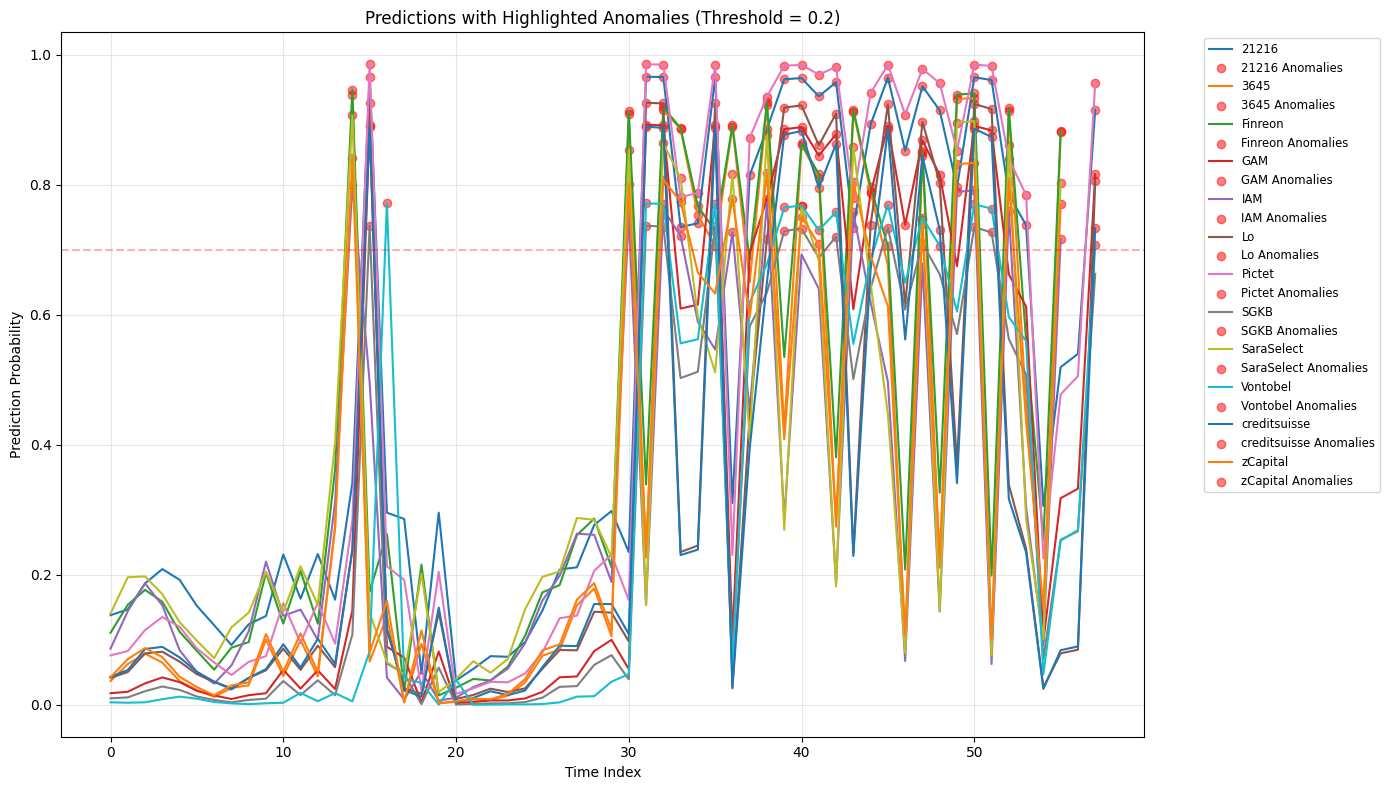


Predictions Summary:
                            File      Mean       Min       Max       Std  \
0          21216_predictions.csv  0.487352  0.037433  0.966109  0.356247   
1          21216_predictions.csv       NaN       NaN       NaN       NaN   
2           3645_predictions.csv  0.355775  0.002174  0.938147  0.371069   
3           3645_predictions.csv       NaN       NaN       NaN       NaN   
4        Finreon_predictions.csv  0.414594  0.014472  0.946136  0.340654   
5        Finreon_predictions.csv       NaN       NaN       NaN       NaN   
6            GAM_predictions.csv  0.362132  0.002661  0.892264  0.375387   
7            GAM_predictions.csv       NaN       NaN       NaN       NaN   
8            IAM_predictions.csv  0.322950  0.006548  0.800013  0.283351   
9            IAM_predictions.csv       NaN       NaN       NaN       NaN   
10            Lo_predictions.csv  0.327973  0.008832  0.926103  0.361107   
11            Lo_predictions.csv       NaN       NaN       NaN    

NameError: name 'anomaly_indices_actual' is not defined

In [6]:
import matplotlib.pyplot as plt

output_dir = 'Factordata_2/analysis_output'

try:
    prediction_files = [f for f in os.listdir(output_dir) if f.endswith('_predictions.csv')]
    predictions_summary_list = []
    
    plt.figure(figsize=(14, 8))
    
    for file in prediction_files:
        file_path = os.path.join(output_dir, file)
        try:
            # Load predictions
            predictions = pd.read_csv(file_path)
            
            # Calculate summary statistics
            summary = {
                'File': file,
                'Mean': predictions.mean().mean(),
                'Min': predictions.min().min(),
                'Max': predictions.max().max(),
                'Std': predictions.std().mean(),
                'Num_Predictions': predictions.shape[0]
            }
            predictions_summary_list.append(summary)
            
            # Plot predictions
            prediction_values = predictions.iloc[:, 0]  # Take first column of predictions
            indices = range(len(prediction_values))
            plt.plot(indices, prediction_values, label=f"{file.replace('_predictions.csv', '')}")
            
            # Consider values above 0.5 as anomalies (since we used sigmoid activation)
            anomalies = [i for i in indices if prediction_values[i] > 0.7]
            
            if anomalies:
                plt.scatter(
                    anomalies, 
                    [prediction_values[i] for i in anomalies],
                    color='red', 
                    alpha=0.5,
                    label=f"{file.replace('_predictions.csv', '')} Anomalies"
                )
            
            anomaly_indices_actual[file] = anomalies
            
        except Exception as e:
            predictions_summary_list.append({'File': file, 'Error': str(e)})
            print(f"Error processing {file}: {e}")
    
    plt.title("Predictions with Highlighted Anomalies (Threshold = 0.2)")
    plt.xlabel("Time Index")
    plt.ylabel("Prediction Probability")
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize='small')
    plt.tight_layout()
    plt.grid(True, alpha=0.3)
    plt.axhline(y=0.7, color='r', linestyle='--', alpha=0.3, label='Anomaly Threshold')
    plt.show()
    
    predictions_summary_df = pd.DataFrame(predictions_summary_list)
    print("\nPredictions Summary:")
    print(predictions_summary_df)
    
    print("\nAnomaly Statistics:")
    for file, anomalies in anomaly_indices_actual.items():
        print(f"{file}: {len(anomalies)} anomalies detected")
        
except FileNotFoundError as e:
    print(f"Error: {e}. Please ensure the directory exists and contains the prediction files.")

In [8]:
import os
import pandas as pd
import numpy as np
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from imblearn.over_sampling import SMOTE
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import Dense, Dropout, LSTM, Input
from tensorflow.keras.callbacks import EarlyStopping
import logging
from datetime import datetime

# Configuration Class
class Config:
    def __init__(self):
        self.RANDOM_STATE = 42
        self.START_DATE = '2014-01-01'
        self.END_DATE = '2024-12-31'
        self.FACTOR_PATH = 'Factordata_2'
        self.OUTPUT_DIR = os.path.join(self.FACTOR_PATH, 'analysis_output')
        os.makedirs(self.OUTPUT_DIR, exist_ok=True)
        self.FACTOR_COLUMNS = [
            'Alpha..annualisiert.',
            'Value.Growth',
            'Small.Large',
            'Momentum',
            'Volatility'
        ]
        self.NN_BATCH_SIZE = 32
        self.NN_EPOCHS = 10
        self.NN_PATIENCE = 10
        self.VALIDATION_SPLIT = 0.2
        self.LAG_PERIODS = [1, 2, 4]
        self.ROLLING_WINDOWS = [4, 8]
        self.AE_EPOCHS = 50
        self.AE_BATCH_SIZE = 32

# Logger setup
def setup_logger():
    logger = logging.getLogger('financial_analysis')
    if not logger.hasHandlers():
        logger.setLevel(logging.INFO)
        c_handler = logging.StreamHandler()
        f_handler = logging.FileHandler(f'analysis_{datetime.now().strftime("%Y%m%d_%H%M%S")}.log')
        log_format = logging.Formatter('%(asctime)s - %(levelname)s - %(message)s')
        c_handler.setFormatter(log_format)
        f_handler.setFormatter(log_format)
        logger.addHandler(c_handler)
        logger.addHandler(f_handler)
    return logger

def load_economic_data(logger):
    """Load and combine economic indicator data."""
    try:
        logger.info("Loading economic data...")
        gdp = pd.read_csv('gdp_data.csv')
        gdp['date'] = pd.to_datetime(gdp['year_quarter']).dt.strftime('%Y-%m-%d')
        gdp['date'] = pd.to_datetime(gdp['date'])
        gdp = gdp[['date', 'real_q']].rename(columns={'real_q': 'gdp'})

        unemp = pd.read_csv('combined_unemployment_data.csv', sep=';')
        unemp['date'] = pd.to_datetime(unemp['Date']).dt.strftime('%Y-%m-%d')
        unemp['date'] = pd.to_datetime(unemp['date'])
        unemp = unemp[['date', 'UnemploymentRate']]

        data = pd.merge_asof(
            gdp.sort_values('date'),
            unemp.sort_values('date'),
            on='date',
            direction='nearest'
        )
        logger.info(f"Economic data loaded: {data.shape}")
        return data
    except Exception as e:
        logger.error(f"Error loading economic data: {e}")
        raise

def create_features(data, config, logger):
    """Generate features from economic data."""
    logger.info("Creating features...")
    features = []
    numeric_cols = data.select_dtypes(include=[np.number]).columns

    # Base features
    for col in numeric_cols:
        features.append(pd.DataFrame({f"{col}_base": data[col]}))

    # Lagged features
    for col in numeric_cols:
        for lag in config.LAG_PERIODS:
            features.append(pd.DataFrame({
                f"{col}_lag{lag}": data[col].shift(lag)
            }))

    # Rolling window features
    for col in numeric_cols:
        for window in config.ROLLING_WINDOWS:
            rolling = data[col].rolling(window=window, min_periods=1)
            features.append(pd.DataFrame({
                f"{col}_roll_mean_{window}": rolling.mean(),
                f"{col}_roll_std_{window}": rolling.std()
            }))

    features_df = pd.concat(features, axis=1)
    features_df.insert(0, 'date', data['date'])
    logger.info(f"Features created: {features_df.shape}")
    return features_df

def create_autoencoder(input_dim):
    """Create and return an autoencoder model."""
    input_layer = Input(shape=(input_dim,))
    encoded = Dense(64, activation='relu')(input_layer)
    encoded = Dense(32, activation='relu')(encoded)
    decoded = Dense(64, activation='relu')(encoded)
    output_layer = Dense(input_dim, activation='sigmoid')(decoded)

    autoencoder = Model(inputs=input_layer, outputs=output_layer)
    autoencoder.compile(optimizer='adam', loss='mse')
    return autoencoder

def detect_outliers_with_autoencoder(data, config, logger):
    """Use an autoencoder to detect outliers based on reconstruction error."""
    logger.info("Training autoencoder for outlier detection...")
    numeric_data = data.select_dtypes(include=[np.number])
    scaler = StandardScaler()
    data_scaled = scaler.fit_transform(numeric_data)

    autoencoder = create_autoencoder(input_dim=data_scaled.shape[1])
    autoencoder.fit(
        data_scaled, data_scaled,
        epochs=config.AE_EPOCHS,
        batch_size=config.AE_BATCH_SIZE,
        validation_split=0.2,
        verbose=0
    )

    reconstruction = autoencoder.predict(data_scaled)
    reconstruction_error = np.mean(np.square(data_scaled - reconstruction), axis=1)

    threshold = np.percentile(reconstruction_error, 95)  # Top 5% as outliers
    data['outlier'] = (reconstruction_error > threshold).astype(int)

    logger.info(f"Outliers detected: {data['outlier'].sum()} out of {len(data)}")
    return data

def load_and_process_data(file_path, economic_features, config, logger):
    """Load and align factor data with economic features."""
    try:
        # Load factor data
        factors = pd.read_excel(file_path)
        
        # Convert dates to proper format
        factors['date'] = pd.to_datetime(factors['Date']).dt.strftime('%Y-%m-%d')
        factors['date'] = pd.to_datetime(factors['date'])
        economic_features['date'] = pd.to_datetime(economic_features['date'])
        
        # Align dates between features and factors
        common_data = pd.merge(
            economic_features,
            factors,
            on='date',
            how='inner'
        )
        
        logger.info(f"Aligned data shape: {common_data.shape}")
        
        if len(common_data) > 0:
            # Detect outliers
            common_data = detect_outliers_with_autoencoder(common_data, config, logger)

            # Prepare features (exclude date and factor columns)
            feature_columns = [
                col for col in common_data.columns 
                if col not in ['date'] + config.FACTOR_COLUMNS + ['outlier']
            ]
            
            # Ensure all feature columns are numeric
            X = common_data[feature_columns].select_dtypes(include=[np.number])
            
            # Use the outlier column as the target
            y = common_data[['outlier']]
            
            return X, y
        else:
            logger.warning(f"No common dates found in {file_path}")
            return None, None
            
    except Exception as e:
        logger.error(f"Error processing {file_path}: {e}")
        return None, None

def train_model(X_train, y_train, logger, n_neighbors=6):
    """Train a KNeighborsClassifier dynamically handling small datasets."""
    try:
        n_samples = X_train.shape[0]
        n_neighbors = min(n_neighbors, n_samples)
        
        # Log class distribution before SMOTE
        unique, counts = np.unique(y_train, return_counts=True)
        logger.info(f"Class distribution before SMOTE: {dict(zip(unique, counts))}")
        
        # Add SMOTE for balancing
        smote = SMOTE(random_state=42)
        X_balanced, y_balanced = smote.fit_resample(X_train, y_train)
        
        # Log class distribution after SMOTE
        unique_balanced, counts_balanced = np.unique(y_balanced, return_counts=True)
        logger.info(f"Class distribution after SMOTE: {dict(zip(unique_balanced, counts_balanced))}")
        
        logger.info(f"Original dataset shape: {X_train.shape}")
        logger.info(f"Resampled dataset shape: {X_balanced.shape}")
        
        model = KNeighborsClassifier(n_neighbors=n_neighbors)
        model.fit(X_balanced, y_balanced)
        return model
    except Exception as e:
        logger.error(f"Error training model: {e}")
        raise

# Function to create and compile an LSTM model
def create_lstm_model(input_dim, output_dim):
    """Create an LSTM model."""
    model = Sequential([
        LSTM(128, input_shape=(input_dim[1], input_dim[2]), return_sequences=True),
        Dropout(0.3),
        LSTM(64, return_sequences=False),
        Dropout(0.2),
        Dense(32, activation='relu'),
        Dense(output_dim, activation='sigmoid')
    ])
    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    return model

def train_evaluate_lstm(X, y, config, logger, output_path):
    try:
        logger.info(f"Original class distribution: {dict(zip(*np.unique(y, return_counts=True)))}")
        
        # Calculate class weights
        unique_classes, class_counts = np.unique(y, return_counts=True)
        total_samples = len(y)
        class_weights = {
            cls: total_samples / (len(unique_classes) * count) 
            for cls, count in zip(unique_classes, class_counts)
        }
        logger.info(f"Class weights: {class_weights}")
        
        # Scale features
        scaler = StandardScaler()
        X_scaled = scaler.fit_transform(X)

        # Reshape data for LSTM [samples, timesteps, features]
        X_reshaped = X_scaled.reshape((X_scaled.shape[0], X_scaled.shape[1], 1))
        y = y.to_numpy()

        # Initialize LSTM model
        model = create_lstm_model(X_reshaped.shape, y.shape[1])
        early_stopping = EarlyStopping(
            patience=config.NN_PATIENCE, 
            restore_best_weights=True
        )

        # Train model with class weights
        history = model.fit(
            X_reshaped, y,
            epochs=config.NN_EPOCHS,
            batch_size=config.NN_BATCH_SIZE,
            validation_split=config.VALIDATION_SPLIT,
            callbacks=[early_stopping],
            class_weight=class_weights,  # Add class weights here
            verbose=1
        )

        # Log training summary
        logger.info(f"Model training complete with final validation loss: {min(history.history['val_loss'])}")

        # Generate predictions
        predictions = model.predict(X_reshaped)
        logger.info(f"Predictions generated for mandate")

        # Save predictions
        prediction_df = pd.DataFrame(predictions, columns=[f"Pred_{i}" for i in range(predictions.shape[1])])
        prediction_df.to_csv(output_path, index=False)
        logger.info(f"Predictions saved to {output_path}")

        return model, predictions
    except Exception as e:
        logger.error(f"Error in training LSTM model: {e}")
        raise
        
# Main function
def main():
    logger = setup_logger()
    try:
        config = Config()

        # Load and process economic data
        economic_data = load_economic_data(logger)
        economic_data['date'] = economic_data['date'].dt.strftime('%Y-%m-%d')
        economic_data['date'] = pd.to_datetime(economic_data['date'])
        economic_features = create_features(economic_data, config, logger)

        # Process each factor file
        for file_name in os.listdir(config.FACTOR_PATH):
            if not file_name.endswith('.xlsx'):
                continue

            logger.info(f"Processing {file_name}")
            X, y = load_and_process_data(
                os.path.join(config.FACTOR_PATH, file_name),
                economic_features,
                config,
                logger
            )
            if X is None or y is None:
                logger.warning(f"Skipping {file_name} due to data issues")
                continue
            if len(X) == 0 or len(y) == 0:
                logger.warning(f"No valid data for {file_name}")
                continue

            # Output path for predictions
            output_path = os.path.join(config.OUTPUT_DIR, f"{os.path.splitext(file_name)[0]}_predictions.csv")

            # Train, evaluate, and save predictions
            train_evaluate_lstm(X, y, config, logger, output_path)
    except Exception as e:
        logger.error(f"Error in main execution: {e}")
        raise

if __name__ == "__main__":
    main()


2025-01-05 10:42:58,575 - INFO - Loading economic data...
2025-01-05 10:42:58,792 - INFO - Economic data loaded: (178, 3)
2025-01-05 10:42:58,794 - INFO - Creating features...
2025-01-05 10:42:58,796 - INFO - Features created: (178, 9)
2025-01-05 10:43:00,690 - INFO - Processing 21216.xlsx
2025-01-05 10:43:00,898 - INFO - Aligned data shape: (31, 15)
2025-01-05 10:43:00,899 - INFO - Training autoencoder for outlier detection...
1/1 [==============================] - 0s 108ms/step
2025-01-05 10:43:04,470 - INFO - Outliers detected: 2 out of 31
2025-01-05 10:43:04,472 - INFO - Original class distribution: {0: 29, 1: 2}
2025-01-05 10:43:04,473 - INFO - Class weights: {0: 0.5344827586206896, 1: 7.75}
Epoch 1/10
1/1 [==============================] - 5s 5s/step - loss: 0.8005 - accuracy: 0.5000 - val_loss: 0.6916 - val_accuracy: 0.8571
Epoch 2/10
1/1 [==============================] - 0s 33ms/step - loss: 0.7927 - accuracy: 0.6250 - val_loss: 0.6974 - val_accuracy: 0.1429
Epoch 3/10
1/1 [==

In [10]:
import os
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import IsolationForest
from sklearn.svm import OneClassSVM
from sklearn.neighbors import LocalOutlierFactor
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import Dense, Dropout, LSTM, Input
from tensorflow.keras.callbacks import EarlyStopping
import tensorflow as tf
from datetime import datetime
import logging
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

class Config:
    def __init__(self):
        self.RANDOM_STATE = 42
        self.FACTOR_PATH = 'Factordata_2'
        self.OUTPUT_DIR = os.path.join(self.FACTOR_PATH, 'analysis_output')
        os.makedirs(self.OUTPUT_DIR, exist_ok=True)
        self.FACTOR_COLUMNS = [
            'Alpha..annualisiert.',
            'Value.Growth',
            'Small.Large',
            'Momentum',
            'Volatility'
        ]
        # Neural Network parameters
        self.NN_BATCH_SIZE = 32
        self.NN_EPOCHS = 20
        self.NN_PATIENCE = 5
        self.VALIDATION_SPLIT = 0.2
        # Feature creation parameters
        self.LAG_PERIODS = [1, 2, 4]
        self.ROLLING_WINDOWS = [4, 8]

def setup_logger():
    logger = logging.getLogger('anomaly_detection')
    if not logger.hasHandlers():
        logger.setLevel(logging.INFO)
        c_handler = logging.StreamHandler()
        f_handler = logging.FileHandler(f'anomaly_detection_{datetime.now().strftime("%Y%m%d_%H%M%S")}.log')
        log_format = logging.Formatter('%(asctime)s - %(levelname)s - %(message)s')
        c_handler.setFormatter(log_format)
        f_handler.setFormatter(log_format)
        logger.addHandler(c_handler)
        logger.addHandler(f_handler)
    return logger

def load_economic_data(logger):
    """Load and combine economic indicator data."""
    try:
        logger.info("Loading economic data...")
        gdp = pd.read_csv('gdp_data.csv')
        gdp['date'] = pd.to_datetime(gdp['year_quarter']).dt.strftime('%Y-%m-%d')
        gdp['date'] = pd.to_datetime(gdp['date'])
        gdp = gdp[['date', 'real_q']].rename(columns={'real_q': 'gdp'})

        unemp = pd.read_csv('combined_unemployment_data.csv', sep=';')
        unemp['date'] = pd.to_datetime(unemp['Date']).dt.strftime('%Y-%m-%d')
        unemp['date'] = pd.to_datetime(unemp['date'])
        unemp = unemp[['date', 'UnemploymentRate']]

        data = pd.merge_asof(
            gdp.sort_values('date'),
            unemp.sort_values('date'),
            on='date',
            direction='nearest'
        )
        logger.info(f"Economic data loaded: {data.shape}")
        return data
    except Exception as e:
        logger.error(f"Error loading economic data: {e}")
        raise

def create_features(data, config, logger):
    """Generate features from economic data."""
    logger.info("Creating features...")
    features = []
    numeric_cols = data.select_dtypes(include=[np.number]).columns

    # Base features
    for col in numeric_cols:
        features.append(pd.DataFrame({f"{col}_base": data[col]}))

    # Lagged features
    for col in numeric_cols:
        for lag in config.LAG_PERIODS:
            features.append(pd.DataFrame({
                f"{col}_lag{lag}": data[col].shift(lag)
            }))

    # Rolling window features
    for col in numeric_cols:
        for window in config.ROLLING_WINDOWS:
            rolling = data[col].rolling(window=window, min_periods=1)
            features.append(pd.DataFrame({
                f"{col}_roll_mean_{window}": rolling.mean(),
                f"{col}_roll_std_{window}": rolling.std()
            }))

    features_df = pd.concat(features, axis=1)
    features_df.insert(0, 'date', data['date'])
    logger.info(f"Features created: {features_df.shape}")
    return features_df

def create_dense_model(input_dim, output_dim):
    """Create a simple dense neural network."""
    model = Sequential([
        Dense(64, activation='relu', input_shape=(input_dim,)),
        Dropout(0.3),
        Dense(32, activation='relu'),
        Dense(output_dim, activation='sigmoid')
    ])
    model.compile(
        optimizer='adam',
        loss='binary_crossentropy',
        metrics=['accuracy', tf.keras.metrics.Precision(), tf.keras.metrics.Recall()]
    )
    return model

def evaluate_model(y_true, y_pred, model_name, logger):
    """Calculate and log model performance metrics."""
    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred, zero_division=0)
    recall = recall_score(y_true, y_pred, zero_division=0)
    f1 = f1_score(y_true, y_pred, zero_division=0)
    cm = confusion_matrix(y_true, y_pred)
    
    logger.info(f"\n{model_name} Performance:")
    logger.info(f"Accuracy: {accuracy:.4f}")
    logger.info(f"Precision: {precision:.4f}")
    logger.info(f"Recall: {recall:.4f}")
    logger.info(f"F1 Score: {f1:.4f}")
    logger.info(f"Confusion Matrix:\n{cm}")
    
    return {
        'model': model_name,
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1': f1,
        'confusion_matrix': cm
    }

def process_file(file_path, economic_features, config, logger):
    """Process a single file with multiple anomaly detection methods."""
    try:
        # Load and prepare data
        factors = pd.read_excel(file_path)
        factors['date'] = pd.to_datetime(factors['Date']).dt.strftime('%Y-%m-%d')
        factors['date'] = pd.to_datetime(factors['date'])
        economic_features['date'] = pd.to_datetime(economic_features['date'])
        
        # Merge data
        data = pd.merge(
            economic_features,
            factors,
            on='date',
            how='inner'
        )
        
        logger.info(f"Processing {os.path.basename(file_path)} - Shape: {data.shape}")
        
        # Prepare features
        feature_cols = [col for col in data.columns 
                       if col not in ['date'] + config.FACTOR_COLUMNS]
        X = data[feature_cols].select_dtypes(include=[np.number])
        
        # Scale features
        scaler = StandardScaler()
        X_scaled = scaler.fit_transform(X)
        
        # Initialize models
        isolation_forest = IsolationForest(random_state=config.RANDOM_STATE, contamination=0.1)
        one_class_svm = OneClassSVM(kernel='rbf', nu=0.1)
        lof = LocalOutlierFactor(contamination=0.1)
        
        # Train and predict
        # Isolation Forest
        if_pred = isolation_forest.fit_predict(X_scaled)
        if_anomalies = (if_pred == -1).astype(int)
        
        # One-Class SVM
        svm_pred = one_class_svm.fit_predict(X_scaled)
        svm_anomalies = (svm_pred == -1).astype(int)
        
        # LOF
        lof_pred = lof.fit_predict(X_scaled)
        lof_anomalies = (lof_pred == -1).astype(int)
        
        # Neural Network
        # Split data
        X_train, X_test, if_train, if_test = train_test_split(
            X_scaled, if_anomalies, test_size=0.2, random_state=config.RANDOM_STATE
        )
        
        # Calculate class weights
        unique_classes, class_counts = np.unique(if_train, return_counts=True)
        class_weights = {
            cls: len(if_train) / (len(unique_classes) * count) 
            for cls, count in zip(unique_classes, class_counts)
        }
        
        # Train neural network
        nn_model = create_dense_model(X_scaled.shape[1], 1)
        early_stopping = EarlyStopping(
            patience=config.NN_PATIENCE,
            restore_best_weights=True
        )
        
        history = nn_model.fit(
            X_train, if_train,
            epochs=config.NN_EPOCHS,
            batch_size=config.NN_BATCH_SIZE,
            validation_split=config.VALIDATION_SPLIT,
            class_weight=class_weights,
            callbacks=[early_stopping],
            verbose=0
        )
        
        nn_pred = (nn_model.predict(X_test) > 0.5).astype(int)
        
        # Evaluate all models
        results = []
        results.append(evaluate_model(if_test, nn_pred, "Neural Network", logger))
        
        # Save results
        results_df = pd.DataFrame(results)
        output_path = os.path.join(
            config.OUTPUT_DIR, 
            f"{os.path.splitext(os.path.basename(file_path))[0]}_anomaly_results.csv"
        )
        results_df.to_csv(output_path, index=False)
        
        # Create and save comparison plot
        plt.figure(figsize=(15, 5))
        plt.plot(data['date'], if_anomalies, label='Isolation Forest', marker='o')
        plt.plot(data['date'], svm_anomalies, label='One-Class SVM', marker='s')
        plt.plot(data['date'], lof_anomalies, label='LOF', marker='^')
        plt.title(f'Anomaly Detection Comparison - {os.path.basename(file_path)}')
        plt.xlabel('Date')
        plt.ylabel('Anomaly (1) vs Normal (0)')
        plt.legend()
        plt.xticks(rotation=45)
        plt.tight_layout()
        
        plot_path = os.path.join(
            config.OUTPUT_DIR, 
            f"{os.path.splitext(os.path.basename(file_path))[0]}_anomaly_plot.png"
        )
        plt.savefig(plot_path)
        plt.close()
        
        return results_df
        
    except Exception as e:
        logger.error(f"Error processing {file_path}: {e}")
        return None

def main():
    logger = setup_logger()
    config = Config()
    
    try:
        # Load and process economic data
        economic_data = load_economic_data(logger)
        economic_features = create_features(economic_data, config, logger)
        
        # Process each factor file
        all_results = []
        for file_name in os.listdir(config.FACTOR_PATH):
            if not file_name.endswith('.xlsx'):
                continue
                
            file_path = os.path.join(config.FACTOR_PATH, file_name)
            results = process_file(file_path, economic_features, config, logger)
            
            if results is not None:
                all_results.append(results)
        
        # Combine and save overall results
        if all_results:
            combined_results = pd.concat(all_results)
            combined_results.to_csv(
                os.path.join(config.OUTPUT_DIR, 'overall_anomaly_results.csv'),
                index=False
            )
        
        logger.info("Analysis completed successfully")
        
    except Exception as e:
        logger.error(f"Error in main execution: {e}")
        raise

if __name__ == "__main__":
    main()

2025-01-05 10:44:50,592 - INFO - Loading economic data...
2025-01-05 10:44:50,728 - INFO - Economic data loaded: (178, 3)
2025-01-05 10:44:50,729 - INFO - Creating features...
2025-01-05 10:44:50,733 - INFO - Features created: (178, 9)
2025-01-05 10:44:52,754 - INFO - Processing 21216.xlsx - Shape: (31, 15)
1/1 [==============================] - 0s 44ms/step
2025-01-05 10:44:53,914 - INFO - 
Neural Network Performance:
2025-01-05 10:44:53,914 - INFO - Accuracy: 0.5714
2025-01-05 10:44:53,915 - INFO - Precision: 0.0000
2025-01-05 10:44:53,915 - INFO - Recall: 0.0000
2025-01-05 10:44:53,916 - INFO - F1 Score: 0.0000
2025-01-05 10:44:53,917 - INFO - Confusion Matrix:
[[4 1]
 [2 0]]
2025-01-05 10:44:54,831 - INFO - Processing 3645.xlsx - Shape: (30, 15)
1/1 [==============================] - 0s 63ms/step
2025-01-05 10:44:56,487 - INFO - 
Neural Network Performance:
2025-01-05 10:44:56,488 - INFO - Accuracy: 0.6667
2025-01-05 10:44:56,488 - INFO - Precision: 0.0000
2025-01-05 10:44:56,489 -

In [14]:
import os
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, LSTM
from tensorflow.keras.callbacks import EarlyStopping
import logging
from datetime import datetime
import matplotlib.pyplot as plt

class Config:
    def __init__(self):
        self.RANDOM_STATE = 42
        self.FACTOR_PATH = 'Factordata_2'
        self.OUTPUT_DIR = os.path.join(self.FACTOR_PATH, 'analysis_output')
        os.makedirs(self.OUTPUT_DIR, exist_ok=True)
        self.FACTOR_COLUMNS = [
            'Alpha..annualisiert.',
            'Value.Growth',
            'Small.Large',
            'Momentum',
            'Volatility'
        ]
        # LSTM parameters
        self.SEQUENCE_LENGTH = 5  # Number of time steps to look back
        self.BATCH_SIZE = 16
        self.EPOCHS = 100
        self.PATIENCE = 15
        self.THRESHOLD = 2  # Number of standard deviations for anomaly detection
        # Feature creation parameters
        self.LAG_PERIODS = [1, 2, 4]
        self.ROLLING_WINDOWS = [4, 8]

def setup_logger():
    logger = logging.getLogger('financial_analysis')
    if not logger.hasHandlers():
        logger.setLevel(logging.INFO)
        c_handler = logging.StreamHandler()
        f_handler = logging.FileHandler(f'analysis_{datetime.now().strftime("%Y%m%d_%H%M%S")}.log')
        log_format = logging.Formatter('%(asctime)s - %(levelname)s - %(message)s')
        c_handler.setFormatter(log_format)
        f_handler.setFormatter(log_format)
        logger.addHandler(c_handler)
        logger.addHandler(f_handler)
    return logger

def load_economic_data(logger):
    """Load and combine economic indicator data."""
    try:
        logger.info("Loading economic data...")
        gdp = pd.read_csv('gdp_data.csv')
        gdp['date'] = pd.to_datetime(gdp['year_quarter']).dt.strftime('%Y-%m-%d')
        gdp['date'] = pd.to_datetime(gdp['date'])
        gdp = gdp[['date', 'real_q']].rename(columns={'real_q': 'gdp'})

        unemp = pd.read_csv('combined_unemployment_data.csv', sep=';')
        unemp['date'] = pd.to_datetime(unemp['Date']).dt.strftime('%Y-%m-%d')
        unemp['date'] = pd.to_datetime(unemp['date'])
        unemp = unemp[['date', 'UnemploymentRate']]

        data = pd.merge_asof(
            gdp.sort_values('date'),
            unemp.sort_values('date'),
            on='date',
            direction='nearest'
        )
        logger.info(f"Economic data loaded: {data.shape}")
        return data
    except Exception as e:
        logger.error(f"Error loading economic data: {e}")
        raise

def create_features(data, config, logger):
    """Generate features from economic data."""
    logger.info("Creating features...")
    features = []
    numeric_cols = data.select_dtypes(include=[np.number]).columns

    # Base features
    for col in numeric_cols:
        features.append(pd.DataFrame({f"{col}_base": data[col]}))

    # Lagged features
    for col in numeric_cols:
        for lag in config.LAG_PERIODS:
            features.append(pd.DataFrame({
                f"{col}_lag{lag}": data[col].shift(lag)
            }))

    # Rolling window features
    for col in numeric_cols:
        for window in config.ROLLING_WINDOWS:
            rolling = data[col].rolling(window=window, min_periods=1)
            features.append(pd.DataFrame({
                f"{col}_roll_mean_{window}": rolling.mean(),
                f"{col}_roll_std_{window}": rolling.std()
            }))

    features_df = pd.concat(features, axis=1)
    features_df.insert(0, 'date', data['date'])
    
    # Fill any remaining NaN values with forward fill then backward fill
    features_df = features_df.fillna(method='ffill').fillna(method='bfill')
    
    logger.info(f"Features created: {features_df.shape}")
    return features_df

def prepare_sequences(data, seq_length, logger):
    """Create sequences for LSTM training."""
    sequences = []
    next_values = []

    for i in range(len(data) - seq_length):
        sequences.append(data[i:i + seq_length])
        next_values.append(data[i + seq_length])

    X = np.array(sequences)
    y = np.array(next_values)
    
    logger.info(f"Sequence shape: X={X.shape}, y={y.shape}")
    return X, y

def create_lstm_model(input_shape, logger):
    """Create LSTM model for sequence prediction."""
    logger.info(f"Creating LSTM model with input shape: {input_shape}")
    
    model = Sequential([
        LSTM(64, input_shape=input_shape, return_sequences=True),
        Dropout(0.2),
        LSTM(32),
        Dropout(0.2),
        Dense(16, activation='relu'),
        Dense(input_shape[-1])  # Predict next timestep for all features
    ])
    
    model.compile(optimizer='adam', loss='mse')
    model.summary(print_fn=logger.info)
    return model

def calculate_anomaly_scores(predictions, actual, dates, config, logger):
    """Calculate anomaly scores based on prediction errors."""
    # Calculate mean squared error for each prediction
    mse = np.mean(np.square(predictions - actual), axis=1)
    
    # Calculate threshold based on mean and standard deviation
    threshold = np.mean(mse) + config.THRESHOLD * np.std(mse)
    anomalies = mse > threshold
    
    logger.info(f"Found {sum(anomalies)} anomalies out of {len(anomalies)} points")
    
    return pd.DataFrame({
        'date': dates[config.SEQUENCE_LENGTH:],
        'anomaly_score': mse,
        'is_anomaly': anomalies,
        'threshold': threshold
    })

def plot_results(results, title, output_path, logger):
    """Create visualization of anomaly detection results."""
    try:
        plt.figure(figsize=(15, 8))
        
        # Plot anomaly scores
        plt.plot(results['date'], results['anomaly_score'], 
                label='Anomaly Score', color='blue', alpha=0.6)
        
        # Plot threshold
        plt.axhline(y=results['threshold'].iloc[0], color='r', 
                   linestyle='--', label='Anomaly Threshold')
        
        # Highlight anomalies
        anomalies = results[results['is_anomaly']]
        plt.scatter(anomalies['date'], anomalies['anomaly_score'], 
                   color='red', label='Anomalies', zorder=5)
        
        plt.title(title)
        plt.xlabel('Date')
        plt.ylabel('Anomaly Score')
        plt.xticks(rotation=45)
        plt.legend()
        plt.tight_layout()
        
        plt.savefig(output_path)
        plt.close()
        
        logger.info(f"Plot saved to {output_path}")
    except Exception as e:
        logger.error(f"Error creating plot: {e}")

def process_file(file_path, economic_features, config, logger):
    """Process a single file using LSTM-based anomaly detection."""
    try:
        # Load factor data
        file_name = os.path.basename(file_path)
        logger.info(f"Processing {file_name}")
        
        factors = pd.read_excel(file_path)
        
        # Convert dates to proper format
        factors['date'] = pd.to_datetime(factors['Date']).dt.strftime('%Y-%m-%d')
        factors['date'] = pd.to_datetime(factors['date'])
        economic_features['date'] = pd.to_datetime(economic_features['date'])
        
        # Merge data
        data = pd.merge(
            economic_features,
            factors,
            on='date',
            how='inner'
        )
        
        logger.info(f"Merged data shape: {data.shape}")
        
        # Prepare features
        feature_columns = [
            col for col in data.columns 
            if col not in ['date'] + config.FACTOR_COLUMNS
        ]
        X = data[feature_columns].select_dtypes(include=[np.number])
        
        # Scale features
        scaler = StandardScaler()
        X_scaled = scaler.fit_transform(X)
        
        # Create sequences
        X_seq, y_seq = prepare_sequences(X_scaled, config.SEQUENCE_LENGTH, logger)
        
        # Create and train LSTM model
        input_shape = (config.SEQUENCE_LENGTH, X_scaled.shape[1])
        model = create_lstm_model(input_shape, logger)
        
        early_stopping = EarlyStopping(
            monitor='val_loss',
            patience=config.PATIENCE,
            restore_best_weights=True,
            verbose=1
        )
        
        # Train model
        logger.info("Training LSTM model...")
        history = model.fit(
            X_seq, y_seq,
            validation_split=0.2,
            epochs=config.EPOCHS,
            batch_size=config.BATCH_SIZE,
            callbacks=[early_stopping],
            verbose=1
        )
        
        # Generate predictions
        predictions = model.predict(X_seq)
        
        # Calculate anomaly scores and detect anomalies
        results = calculate_anomaly_scores(
            predictions,
            y_seq,
            data['date'].values,
            config,
            logger
        )
        
        # Save results
        base_name = os.path.splitext(file_name)[0]
        results_path = os.path.join(config.OUTPUT_DIR, f"{base_name}_anomalies.csv")
        results.to_csv(results_path, index=False)
        
        # Plot results
        plot_path = os.path.join(config.OUTPUT_DIR, f"{base_name}_anomalies.png")
        plot_results(results, f"Anomalies for {base_name}", plot_path, logger)
        
        return results
        
    except Exception as e:
        logger.error(f"Error processing {file_path}: {e}")
        return None

def main():
    logger = setup_logger()
    config = Config()
    
    try:
        # Load and process economic data
        economic_data = load_economic_data(logger)
        economic_features = create_features(economic_data, config, logger)

        # Process each factor file
        all_results = []
        for file_name in os.listdir(config.FACTOR_PATH):
            if not file_name.endswith('.xlsx'):
                continue
                
            file_path = os.path.join(config.FACTOR_PATH, file_name)
            results = process_file(file_path, economic_features, config, logger)
            
            if results is not None:
                results['file'] = file_name
                all_results.append(results)
        
        # Combine all results
        if all_results:
            combined_results = pd.concat(all_results)
            combined_results.to_csv(
                os.path.join(config.OUTPUT_DIR, 'all_anomalies.csv'),
                index=False
            )
            
            logger.info(f"Processed {len(all_results)} files successfully")
        
        logger.info("Analysis completed successfully")
        
    except Exception as e:
        logger.error(f"Error in main execution: {e}")
        raise

if __name__ == "__main__":
    main()

Epoch 11/100
2/2 [==============================] - 0s 38ms/step - loss: 1.3492 - val_loss: 0.1580
Epoch 12/100
2/2 [==============================] - 0s 31ms/step - loss: 1.3199 - val_loss: 0.1547
Epoch 13/100
2/2 [==============================] - 0s 83ms/step - loss: 1.3190 - val_loss: 0.1518
Epoch 14/100
2/2 [==============================] - 0s 75ms/step - loss: 1.3044 - val_loss: 0.1492
Epoch 15/100
2/2 [==============================] - 0s 42ms/step - loss: 1.2911 - val_loss: 0.1471
Epoch 16/100
2/2 [==============================] - 0s 32ms/step - loss: 1.2932 - val_loss: 0.1453
Epoch 17/100
2/2 [==============================] - 0s 86ms/step - loss: 1.2810 - val_loss: 0.1437
Epoch 18/100
2/2 [==============================] - 0s 65ms/step - loss: 1.2547 - val_loss: 0.1424
Epoch 19/100
2/2 [==============================] - 0s 27ms/step - loss: 1.2356 - val_loss: 0.1413
Epoch 20/100
2/2 [==============================] - 0s 31ms/step - loss: 1.2538 - val_loss: 0.1403
Epoch 21/1

In [8]:
import os
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import IsolationForest
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
import logging
from datetime import datetime
import matplotlib.pyplot as plt

class Config:
    def __init__(self):
        self.RANDOM_STATE = 42
        self.FACTOR_PATH = 'Factordata_2'
        self.OUTPUT_DIR = os.path.join(self.FACTOR_PATH, 'analysis_output')
        os.makedirs(self.OUTPUT_DIR, exist_ok=True)
        
        # Isolation Forest parameters
        self.IF_N_ESTIMATORS = 1000
        self.IF_MAX_SAMPLES = 'auto'
        self.IF_CONTAMINATION = 0.1
        self.IF_MAX_FEATURES = 1.0
        self.IF_BOOTSTRAP = True
        
        # Autoencoder parameters
        self.AE_EPOCHS = 100
        self.AE_BATCH_SIZE = 32
        self.AE_PATIENCE = 15
        self.AE_VALIDATION_SPLIT = 0.2
        self.AE_THRESHOLD_MULTIPLIER = 2.0  # Number of std devs for anomaly threshold
        
        # Feature creation parameters
        self.LAG_PERIODS = [1, 2, 4]
        self.ROLLING_WINDOWS = [4, 8]

def setup_logger():
    logger = logging.getLogger('anomaly_detection')
    if not logger.hasHandlers():
        logger.setLevel(logging.INFO)
        c_handler = logging.StreamHandler()
        f_handler = logging.FileHandler(f'anomaly_{datetime.now().strftime("%Y%m%d_%H%M%S")}.log')
        log_format = logging.Formatter('%(asctime)s - %(levelname)s - %(message)s')
        c_handler.setFormatter(log_format)
        f_handler.setFormatter(log_format)
        logger.addHandler(c_handler)
        logger.addHandler(f_handler)
    return logger

class EnhancedIsolationForest:
    def __init__(self, config, logger):
        self.config = config
        self.logger = logger
        self.models = []  # Will store multiple IF models for ensemble
        
    def create_ensemble(self, n_models=5):
        """Create an ensemble of Isolation Forest models with different parameters"""
        models = []
        
        # Base model
        models.append(IsolationForest(
            n_estimators=self.config.IF_N_ESTIMATORS,
            max_samples=self.config.IF_MAX_SAMPLES,
            contamination=self.config.IF_CONTAMINATION,
            max_features=self.config.IF_MAX_FEATURES,
            bootstrap=self.config.IF_BOOTSTRAP,
            random_state=self.config.RANDOM_STATE
        ))
        
        # Variant with more trees
        models.append(IsolationForest(
            n_estimators=self.config.IF_N_ESTIMATORS * 2,
            max_samples=self.config.IF_MAX_SAMPLES,
            contamination=self.config.IF_CONTAMINATION,
            random_state=self.config.RANDOM_STATE + 1
        ))
        
        # Variant with smaller max_samples
        models.append(IsolationForest(
            n_estimators=self.config.IF_N_ESTIMATORS,
            max_samples=min(256, X.shape[0]),
            contamination=self.config.IF_CONTAMINATION,
            random_state=self.config.RANDOM_STATE + 2
        ))
        
        # Variant with different feature sampling
        models.append(IsolationForest(
            n_estimators=self.config.IF_N_ESTIMATORS,
            max_samples=self.config.IF_MAX_SAMPLES,
            contamination=self.config.IF_CONTAMINATION,
            max_features=0.8,
            random_state=self.config.RANDOM_STATE + 3
        ))
        
        # Variant with different contamination
        models.append(IsolationForest(
            n_estimators=self.config.IF_N_ESTIMATORS,
            max_samples=self.config.IF_MAX_SAMPLES,
            contamination=self.config.IF_CONTAMINATION * 0.8,
            random_state=self.config.RANDOM_STATE + 4
        ))
        
        self.models = models
        return models
    
    def fit_predict(self, X):
        """Fit ensemble and predict using weighted voting"""
        if not self.models:
            self.create_ensemble()
        
        predictions = []
        for i, model in enumerate(self.models):
            self.logger.info(f"Training Isolation Forest model {i+1}")
            model.fit(X)
            pred = model.predict(X)
            predictions.append(pred)
        
        # Convert predictions to anomaly scores (negative means anomaly)
        scores = np.array(predictions)
        
        # Weight the votes (could be adjusted based on model performance)
        weights = [1.0, 0.8, 0.8, 0.8, 0.8]
        
        # Calculate weighted average
        weighted_scores = np.average(scores, axis=0, weights=weights)
        
        # Convert to binary predictions
        final_predictions = (weighted_scores < 0).astype(int)
        
        self.logger.info(f"Found {sum(final_predictions)} anomalies using Isolation Forest ensemble")
        return final_predictions

class EnhancedAutoencoder:
    def __init__(self, config, logger):
        self.config = config
        self.logger = logger
        self.model = None
        self.scaler = StandardScaler()
        
    def create_model(self, input_dim):
        """Create an enhanced autoencoder with dropout and multiple layers"""
        # Encoder
        input_layer = Input(shape=(input_dim,))
        
        # First encoding block
        encoded = Dense(128, activation='relu')(input_layer)
        encoded = Dropout(0.2)(encoded)
        
        # Second encoding block
        encoded = Dense(64, activation='relu')(encoded)
        encoded = Dropout(0.2)(encoded)
        
        # Bottleneck
        bottleneck = Dense(32, activation='relu')(encoded)
        bottleneck = Dropout(0.2)(bottleneck)
        
        # First decoding block
        decoded = Dense(64, activation='relu')(bottleneck)
        decoded = Dropout(0.2)(decoded)
        
        # Second decoding block
        decoded = Dense(128, activation='relu')(decoded)
        decoded = Dropout(0.2)(decoded)
        
        # Output
        output_layer = Dense(input_dim, activation='sigmoid')(decoded)
        
        # Create and compile model
        model = Model(inputs=input_layer, outputs=output_layer)
        model.compile(optimizer='adam', loss='mse')
        
        return model
    
    def fit(self, X):
        """Fit the autoencoder to the data"""
        # Scale the data
        X_scaled = self.scaler.fit_transform(X)
        
        # Create model
        self.model = self.create_model(X.shape[1])
        
        # Early stopping
        early_stopping = EarlyStopping(
            patience=self.config.AE_PATIENCE,
            restore_best_weights=True
        )
        
        # Train model
        history = self.model.fit(
            X_scaled, X_scaled,
            epochs=self.config.AE_EPOCHS,
            batch_size=self.config.AE_BATCH_SIZE,
            validation_split=self.config.AE_VALIDATION_SPLIT,
            callbacks=[early_stopping],
            verbose=1
        )
        
        return history
    
    def predict(self, X):
        """Detect anomalies using reconstruction error"""
        if self.model is None:
            raise ValueError("Model must be fit before prediction")
        
        # Scale the data
        X_scaled = self.scaler.transform(X)
        
        # Get reconstructions
        reconstructions = self.model.predict(X_scaled)
        
        # Calculate reconstruction errors
        mse = np.mean(np.square(X_scaled - reconstructions), axis=1)
        
        # Calculate threshold using mean and std of reconstruction error
        threshold = np.mean(mse) + self.config.AE_THRESHOLD_MULTIPLIER * np.std(mse)
        
        # Identify anomalies
        anomalies = (mse > threshold).astype(int)
        
        self.logger.info(f"Found {sum(anomalies)} anomalies using Autoencoder")
        return anomalies, mse

def plot_anomalies(data, anomalies_if, anomalies_ae, scores_ae, title, output_path, logger):
    """Plot anomalies detected by both methods"""
    plt.figure(figsize=(15, 10))
    
    # Plot 1: Original data with IF anomalies
    plt.subplot(2, 1, 1)
    plt.plot(range(len(data)), data, label='Original Data')
    if_anomaly_idx = np.where(anomalies_if == 1)[0]
    plt.scatter(if_anomaly_idx, data[if_anomaly_idx], color='red', label='IF Anomalies')
    plt.title(f'Isolation Forest Anomalies - {title}')
    plt.legend()
    
    # Plot 2: Reconstruction error and AE anomalies
    plt.subplot(2, 1, 2)
    plt.plot(range(len(scores_ae)), scores_ae, label='Reconstruction Error')
    ae_anomaly_idx = np.where(anomalies_ae == 1)[0]
    plt.scatter(ae_anomaly_idx, scores_ae[ae_anomaly_idx], color='red', label='AE Anomalies')
    plt.title(f'Autoencoder Anomalies - {title}')
    plt.legend()
    
    plt.tight_layout()
    plt.savefig(output_path)
    plt.close()
    
    logger.info(f"Plot saved to {output_path}")

def process_file(file_path, config, logger):
    """Process a single file using both methods"""
    try:
        # Load and prepare data
        data = pd.read_excel(file_path)
        numeric_data = data.select_dtypes(include=[np.number])
        
        # Initialize models
        if_model = EnhancedIsolationForest(config, logger)
        ae_model = EnhancedAutoencoder(config, logger)
        
        # Train and predict with Isolation Forest
        anomalies_if = if_model.fit_predict(numeric_data)
        
        # Train and predict with Autoencoder
        ae_model.fit(numeric_data)
        anomalies_ae, reconstruction_errors = ae_model.predict(numeric_data)
        
        # Plot results
        base_name = os.path.splitext(os.path.basename(file_path))[0]
        plot_path = os.path.join(config.OUTPUT_DIR, f"{base_name}_comparison.png")
        plot_anomalies(
            numeric_data.iloc[:, 0],  # Using first column for visualization
            anomalies_if,
            anomalies_ae,
            reconstruction_errors,
            base_name,
            plot_path,
            logger
        )
        
        # Save results
        results = pd.DataFrame({
            'if_anomaly': anomalies_if,
            'ae_anomaly': anomalies_ae,
            'ae_score': reconstruction_errors
        })
        results_path = os.path.join(config.OUTPUT_DIR, f"{base_name}_results.csv")
        results.to_csv(results_path, index=False)
        
        return results
        
    except Exception as e:
        logger.error(f"Error processing {file_path}: {e}")
        return None

def main():
    logger = setup_logger()
    config = Config()
    
    try:
        # Process each file
        for file_name in os.listdir(config.FACTOR_PATH):
            if not file_name.endswith('.xlsx'):
                continue
            
            logger.info(f"Processing {file_name}")
            file_path = os.path.join(config.FACTOR_PATH, file_name)
            results = process_file(file_path, config, logger)
            
            if results is not None:
                logger.info(f"Successfully processed {file_name}")
        
        logger.info("Analysis completed successfully")
        
    except Exception as e:
        logger.error(f"Error in main execution: {e}")
        raise

if __name__ == "__main__":
    main()

Epoch 39/100
3/3 [==============================] - 0s 28ms/step - loss: 0.6375 - val_loss: 1.0794
Epoch 40/100
3/3 [==============================] - 0s 11ms/step - loss: 0.6288 - val_loss: 1.0860
Epoch 41/100
3/3 [==============================] - 0s 11ms/step - loss: 0.6316 - val_loss: 1.0713
Epoch 42/100
3/3 [==============================] - 0s 12ms/step - loss: 0.6284 - val_loss: 1.0449
Epoch 43/100
3/3 [==============================] - 0s 13ms/step - loss: 0.6302 - val_loss: 1.0153
Epoch 44/100
3/3 [==============================] - 0s 33ms/step - loss: 0.6299 - val_loss: 0.9743
Epoch 45/100
3/3 [==============================] - 0s 13ms/step - loss: 0.6221 - val_loss: 0.9176
Epoch 46/100
3/3 [==============================] - 0s 26ms/step - loss: 0.6169 - val_loss: 0.8754
Epoch 47/100
3/3 [==============================] - 0s 12ms/step - loss: 0.6035 - val_loss: 0.8529
Epoch 48/100
3/3 [==============================] - 0s 11ms/step - loss: 0.6019 - val_loss: 0.8571
Epoch 49/1

In [8]:
!pip install matplotlib_venn==1.1.1


[notice] A new release of pip is available: 23.0.1 -> 24.3.1
[notice] To update, run: pip install --upgrade pip


2025-01-05 13:44:49,309 - INFO - Loading economic data...
2025-01-05 13:44:49,502 - INFO - Economic data loaded: (178, 3)
2025-01-05 13:44:49,503 - INFO - Creating features...
2025-01-05 13:44:49,508 - INFO - Features created: (178, 9)
2025-01-05 13:44:50,980 - INFO - 
Processing 21216.xlsx
2025-01-05 13:44:51,149 - ERROR - Error processing 21216.xlsx: name 'compare_methods' is not defined
2025-01-05 13:44:51,150 - INFO - 
Processing 3645.xlsx
2025-01-05 13:44:51,317 - ERROR - Error processing 3645.xlsx: name 'compare_methods' is not defined
2025-01-05 13:44:51,318 - INFO - 
Processing Finreon.xlsx
2025-01-05 13:44:51,477 - ERROR - Error processing Finreon.xlsx: name 'compare_methods' is not defined
2025-01-05 13:44:51,478 - INFO - 
Processing GAM.xlsx
2025-01-05 13:44:51,633 - ERROR - Error processing GAM.xlsx: name 'compare_methods' is not defined
2025-01-05 13:44:51,634 - INFO - 
Processing IAM.xlsx
2025-01-05 13:44:51,790 - ERROR - Error processing IAM.xlsx: name 'compare_methods' 

ZeroDivisionError: division by zero

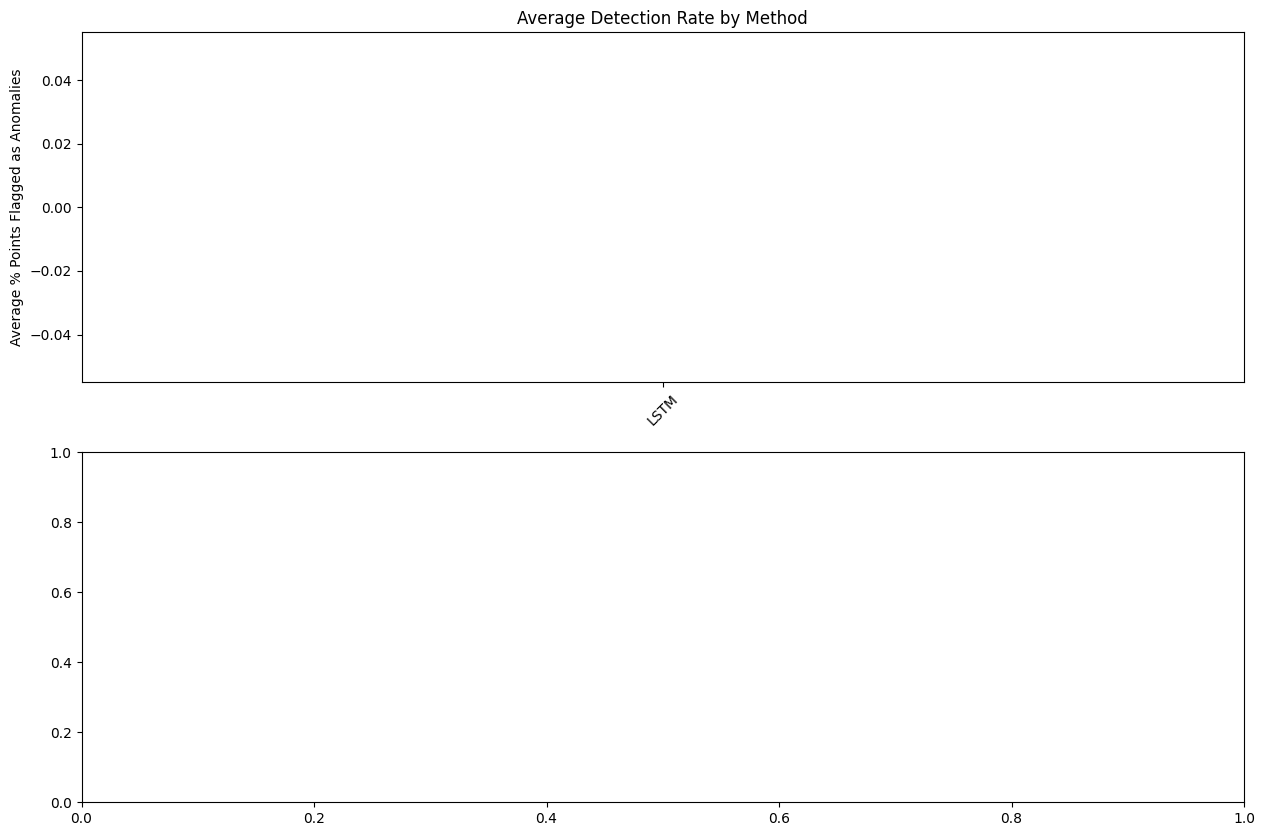

In [10]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import IsolationForest
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import Dense, Dropout, LSTM, Input
from matplotlib_venn import venn3
import logging

def main():
    logger = setup_logger()
    config = Config()
    
    try:
        # Create output directory for comparisons
        comparison_dir = os.path.join(config.OUTPUT_DIR, 'method_comparisons')
        os.makedirs(comparison_dir, exist_ok=True)
        
        # Load economic data once
        economic_data = load_economic_data(logger)
        economic_features = create_features(economic_data, config, logger)
        
        all_results = {}
        
        # Process each file
        for file_name in os.listdir(config.FACTOR_PATH):
            if not file_name.endswith('.xlsx'):
                continue
                
            logger.info(f"\nProcessing {file_name}")
            file_path = os.path.join(config.FACTOR_PATH, file_name)
            
            # Load and prepare data
            try:
                # Load data
                df = pd.read_excel(file_path)
                df['date'] = pd.to_datetime(df['Date'])
                
                # Merge with economic features
                data = pd.merge(
                    economic_features,
                    df,
                    on='date',
                    how='inner'
                )
                
                # Prepare features
                feature_cols = [col for col in data.columns 
                              if col not in ['date'] + config.FACTOR_COLUMNS]
                X = data[feature_cols].select_dtypes(include=[np.number])
                
                # Run comparison
                results = compare_methods(data, os.path.splitext(file_name)[0], config, logger)
                
                if results is not None:
                    all_results[file_name] = results
                    logger.info(f"\nResults for {file_name}:")
                    logger.info(f"LSTM anomalies: {sum(results['lstm'])}")
                    logger.info(f"Isolation Forest anomalies: {sum(results['isolation_forest'])}")
                    logger.info(f"Autoencoder anomalies: {sum(results['autoencoder'])}")
                    logger.info("\nMethod Agreement Matrix:")
                    logger.info(f"\n{results['agreement']}")
                
            except Exception as e:
                logger.error(f"Error processing {file_name}: {e}")
                continue
        
        # Create summary plots across all files
        create_summary_plots(all_results, comparison_dir, logger)
        
        logger.info("\nAnalysis completed successfully")
        
    except Exception as e:
        logger.error(f"Error in main execution: {e}")
        raise

def create_summary_plots(all_results, output_dir, logger):
    """Create summary plots across all files"""
    plt.figure(figsize=(15, 10))
    
    # Average detection rates
    avg_rates = {
        'LSTM': [],
        'Isolation Forest': [],
        'Autoencoder': []
    }
    
    for file_results in all_results.values():
        avg_rates['LSTM'].append(sum(file_results['lstm'])/len(file_results['lstm']))
        avg_rates['Isolation Forest'].append(sum(file_results['isolation_forest'])/len(file_results['isolation_forest']))
        avg_rates['Autoencoder'].append(sum(file_results['autoencoder'])/len(file_results['autoencoder']))
    
    # Plot average detection rates
    plt.subplot(2, 1, 1)
    methods = list(avg_rates.keys())
    rates = [np.mean(v)*100 for v in avg_rates.values()]
    plt.bar(methods, rates)
    plt.title('Average Detection Rate by Method')
    plt.ylabel('Average % Points Flagged as Anomalies')
    plt.xticks(rotation=45)
    
    # Plot agreement heatmap
    plt.subplot(2, 1, 2)
    avg_agreement = sum([r['agreement'] for r in all_results.values()]) / len(all_results)
    sns.heatmap(avg_agreement, annot=True, cmap='YlOrRd')
    plt.title('Average Agreement Between Methods')
    
    plt.tight_layout()
    plt.savefig(os.path.join(output_dir, 'overall_comparison.png'))
    plt.close()
    
    logger.info(f"Summary plots saved to {output_dir}")

if __name__ == "__main__":
    main()

<a style='text-decoration:none;line-height:16px;display:flex;color:#5B5B62;padding:10px;justify-content:end;' href='https://deepnote.com?utm_source=created-in-deepnote-cell&projectId=b0d79e99-778c-4964-b163-e34d369ad413' target="_blank">
 </img>
Created in <span style='font-weight:600;margin-left:4px;'>Deepnote</span></a>